In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/car data.csv")

In [3]:
df.head(10)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
LE = LabelEncoder()
df['Car_Name'] = LE.fit_transform(df['Car_Name'])
df['Fuel_Type'] = LE.fit_transform(df['Fuel_Type'])
df['Selling_type'] = LE.fit_transform(df['Selling_type'])
df['Transmission'] = LE.fit_transform(df['Transmission'])

In [7]:
SS = StandardScaler()
df['Year'] = SS.fit_transform(df[['Year']])
df['Driven_kms'] = SS.fit_transform(df[['Driven_kms']])

In [8]:
df.head(10)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,90,0.128897,3.35,5.59,-0.256224,2,0,1,0
1,93,-0.217514,4.75,9.54,0.155911,1,0,1,0
2,68,1.168129,7.25,9.85,-0.773969,2,0,1,0
3,96,-0.910335,2.85,4.15,-0.817758,2,0,1,0
4,92,0.128897,4.60,6.87,0.141743,1,0,1,0
5,95,1.514540,9.25,9.83,-0.898356,1,0,1,0
6,68,0.475308,6.75,8.12,-0.467547,2,0,1,0
7,91,0.475308,6.50,8.61,-0.090623,1,0,1,0
8,68,0.821718,8.75,8.89,-0.429501,1,0,1,0
9,68,0.475308,7.45,8.92,0.139605,1,0,1,0


In [9]:
df.describe()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
count,301.000000,3.010000e+02,301.000000,301.000000,3.010000e+02,301.000000,301.000000,301.000000,301.000000
mean,62.571429,-2.931579e-14,4.661296,7.628472,5.901518e-17,1.787375,0.352159,0.867110,0.043189
std,25.573535,1.001665e+00,5.082812,8.642584,1.001665e+00,0.425801,0.478439,0.340021,0.247915
min,0.000000,-3.681621e+00,0.100000,0.320000,-9.388230e-01,0.000000,0.000000,0.000000,0.000000
25%,47.000000,-5.639244e-01,0.900000,1.200000,-5.653257e-01,2.000000,0.000000,1.000000,0.000000
50%,69.000000,1.288970e-01,3.600000,6.400000,-1.274323e-01,2.000000,0.000000,1.000000,0.000000
75%,82.000000,8.217184e-01,6.000000,9.900000,3.044594e-01,2.000000,1.000000,1.000000,0.000000
max,97.000000,1.514540e+00,35.000000,92.600000,1.192752e+01,2.000000,1.000000,1.000000,3.000000


In [10]:
df.shape

(301, 9)

In [11]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [12]:
X = df.drop('Selling_Price',axis=1)
Y = df['Selling_Price']

In [13]:
X.head()

,Car_Name,Year,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,90,0.128897,5.59,-0.256224,2,0,1,0
1,93,-0.217514,9.54,0.155911,1,0,1,0
2,68,1.168129,9.85,-0.773969,2,0,1,0
3,96,-0.910335,4.15,-0.817758,2,0,1,0
4,92,0.128897,6.87,0.141743,1,0,1,0


In [14]:
Y.head()

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60


In [15]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train,Y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)

In [20]:
r2 = r2_score(Y_test,y_pred)
mse = mean_squared_error(Y_test,y_pred)

In [21]:
r2

0.846454062381602

In [22]:
mse

3.5370204237558203

In [38]:
input = [[92,0.128897,6.87,0.141743,1,0,1,0]]

In [39]:
new_car_price_prediction = model.predict(input)

In [40]:
print("New Predicted Car Price:",new_car_price_prediction)

New Predicted Car Price: [5.72932845]


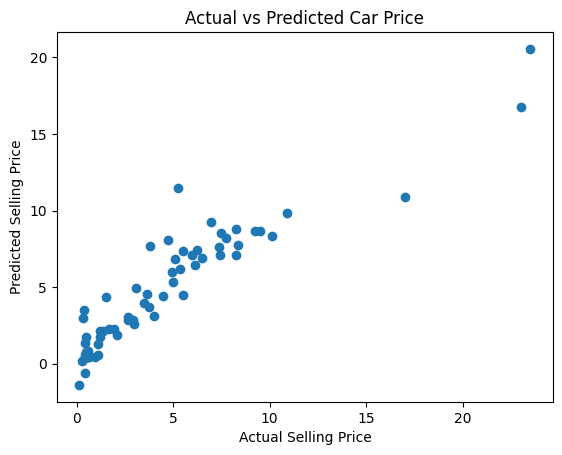

In [41]:
plt.scatter(Y_test,y_pred)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title("Actual vs Predicted Car Price")
plt.show()